**Step 1: Verify Python and TensorFlow Installation**

In [30]:
!python --version !pip show tensorflow

Python 3.11.11


**Step 3: Load the MNIST Dataset**

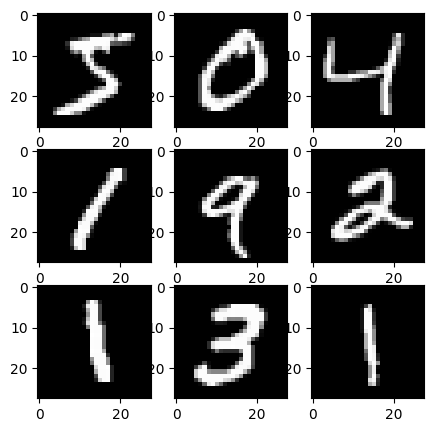

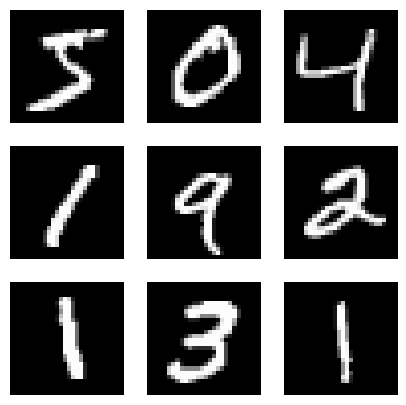

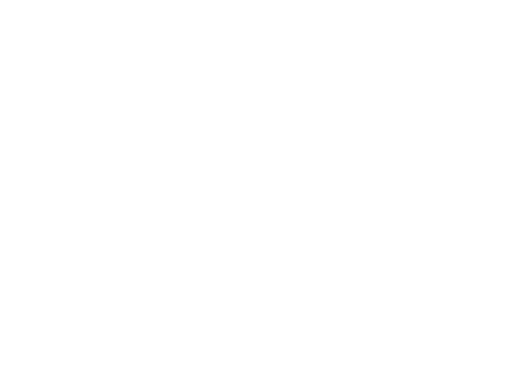

In [31]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (scale pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Show sample images
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (scale pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Show sample images
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis('off')
plt.show()
plt.axis('off')
plt.show()

**Step 4: Define and Train a Neural Network**

In [32]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (scale pixel values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Define model
architecture = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
# Input layer
# (flatten 28x28 pixels)
architecture.add(tf.keras.layers.Dense(128, activation='relu'))
# Hidden layer
architecture.add(tf.keras.layers.Dense(10, activation='softmax'))
# Output layer
# (10 classes)
# Compile model
architecture.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train model
history = architecture.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
# Save trained model
architecture.save("mnist_model.h5")
print("Model training complete and saved as mnist_model.h5")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8785 - loss: 0.4250 - val_accuracy: 0.9580 - val_loss: 0.1397
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9637 - loss: 0.1217 - val_accuracy: 0.9694 - val_loss: 0.0983
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9755 - loss: 0.0815 - val_accuracy: 0.9726 - val_loss: 0.0908
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9820 - loss: 0.0605 - val_accuracy: 0.9770 - val_loss: 0.0764
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9774 - val_loss: 0.0718


Model training complete and saved as mnist_model.h5


**Step 5: Convert the Model to TensorFlow Lite Format**

In [33]:
# Load trained model
model = tf.keras.models.load_model("mnist_model.h5")

# Convert to TensorFlow Lite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)
print("Model converted and saved as mnist_model.tflite")

Saved artifact at '/tmp/tmpydn99hdc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136508540143376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136511266956176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136511266955984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136508540149904: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model converted and saved as mnist_model.tflite


**Step 6: Load the Converted Model Using TensorFlow Lite Interpreter**

In [34]:
# Load TensorFlowlite model interpreter
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("Input Details:", input_details)
print("Output Details:", output_details)

Input Details: [{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


**Step 7: Perform Inference with TensorFlow Lite**

Input Details: [{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Acutual label: 7


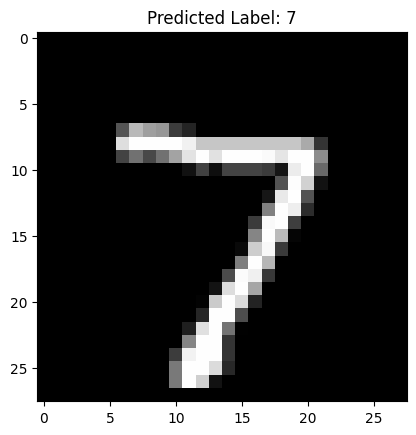

In [36]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Load TensorFlowlite model interpreter
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("Input Details:", input_details)
print("Output Details:", output_details)

# Select a test image
test_image = x_test[0].astype(np.float32)

# Ensure data type matches model input
test_image = np.expand_dims(test_image, axis=0)

# Reshape for model input
interpreter.set_tensor(input_details[0]['index'], test_image)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Display the image and results
# Select a test image
test_image = x_test[0].astype(np.float32)

# Ensure data type matches model input
test_image = np.expand_dims(test_image, axis=0)

# Reshape for model input
interpreter.set_tensor(input_details[0]['index'], test_image)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Display the image and results
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted Label: {predicted_label}")
print(f"Acutual label: {y_test[0]}")
plt.show()